In [1]:
from foolbox import PyTorchModel, accuracy, samples
from foolbox.attacks import LinfPGD
import torch

from adversarial_sinks.modeling.train import CIFAR10Module
from adversarial_sinks.dataset import CIFAR10DataModule
from adversarial_sinks.attacks import run_pgd_attack
from adversarial_sinks.utils import visualize_adversarial_examples, robust_accuracy

2026-05-29 00:10:21.603 | INFO     | adversarial_sinks.config:<module>:11 - PROJ_ROOT path is: /home/mbaj/studia/magisterka/sem1/ZZSN/adversarial-sinks


In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [13]:
module = CIFAR10Module.load_from_checkpoint("models/checkpoints/cifar10-epoch=046-val/acc=0.9336.ckpt")
model = module.model.eval().to(device)

In [14]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)
preprocessing = dict(mean=CIFAR10_MEAN, std=CIFAR10_STD, axis=-3)

In [15]:
fmodel = PyTorchModel(model, bounds=(0, 1), preprocessing=preprocessing)

In [16]:
dm = CIFAR10DataModule(batch_size=16)
dm.setup()
data_loader = dm.raw_test_dataloader()

In [17]:
epsilons = [
    0.0, 0.0002, 0.0005, 0.0008, 0.001, 0.0015, 0.002, 0.003, 0.01, 0.1, 0.3, 0.5, 1.0
]

In [18]:
results = run_pgd_attack(fmodel, data_loader, epsilons)

In [19]:
eps_acc_dict = robust_accuracy(results)
for eps, acc in eps_acc_dict.items():
    print(f"Epsilon: {eps:.4f}, Robust Accuracy: {acc:.2%}")

Epsilon: 0.0000, Robust Accuracy: 100.00%
Epsilon: 0.0002, Robust Accuracy: 93.75%
Epsilon: 0.0005, Robust Accuracy: 93.75%
Epsilon: 0.0008, Robust Accuracy: 93.75%
Epsilon: 0.0010, Robust Accuracy: 93.75%
Epsilon: 0.0015, Robust Accuracy: 93.75%
Epsilon: 0.0020, Robust Accuracy: 87.50%
Epsilon: 0.0030, Robust Accuracy: 68.75%
Epsilon: 0.0100, Robust Accuracy: 6.25%
Epsilon: 0.1000, Robust Accuracy: 0.00%
Epsilon: 0.3000, Robust Accuracy: 0.00%
Epsilon: 0.5000, Robust Accuracy: 0.00%
Epsilon: 1.0000, Robust Accuracy: 0.00%


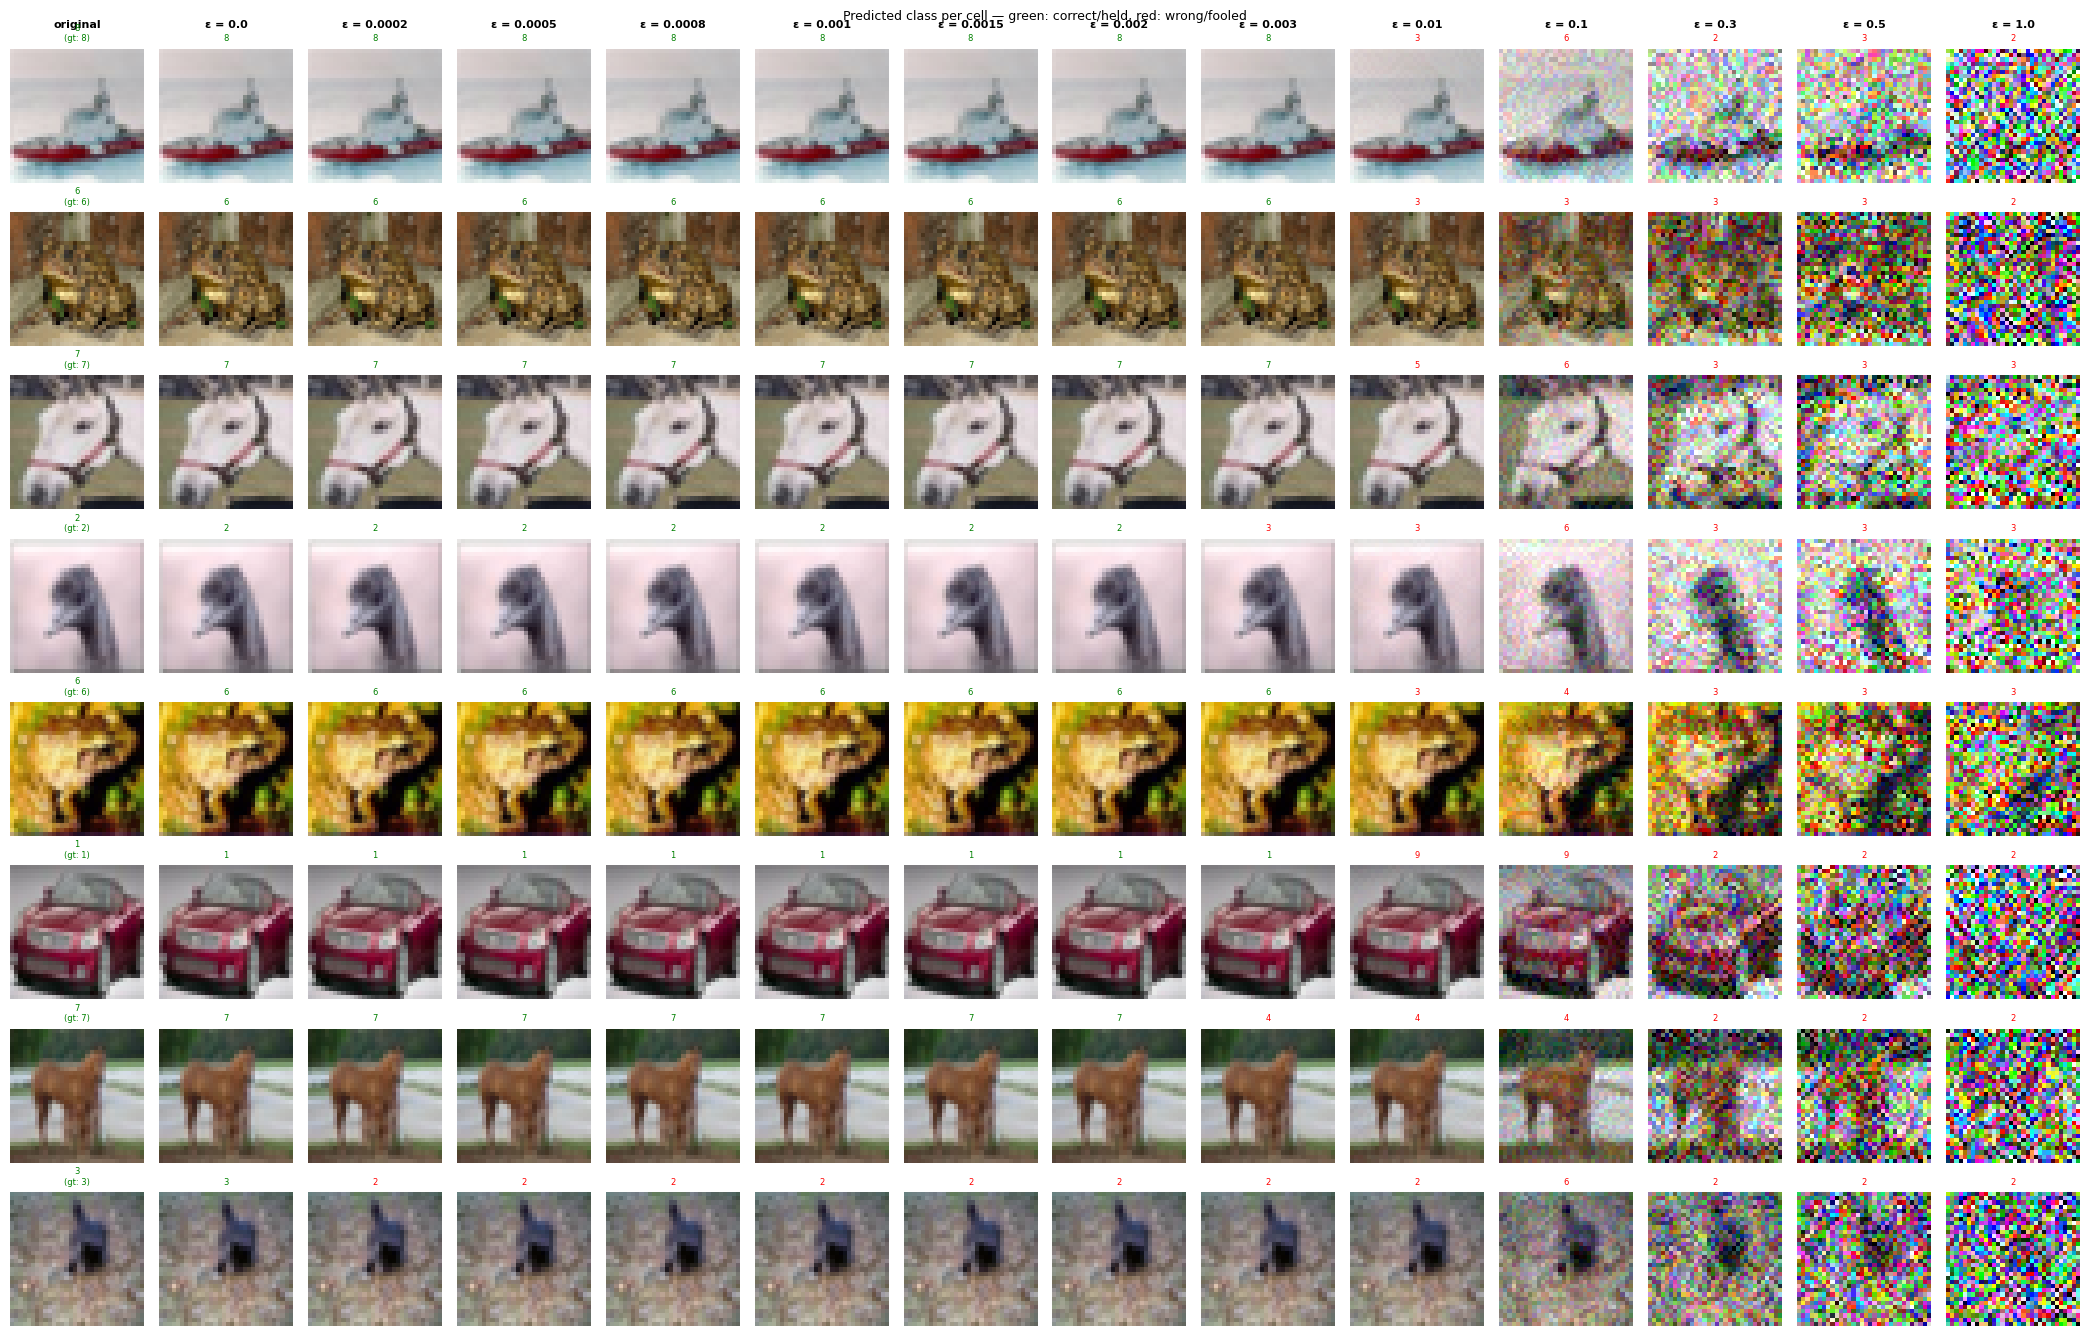

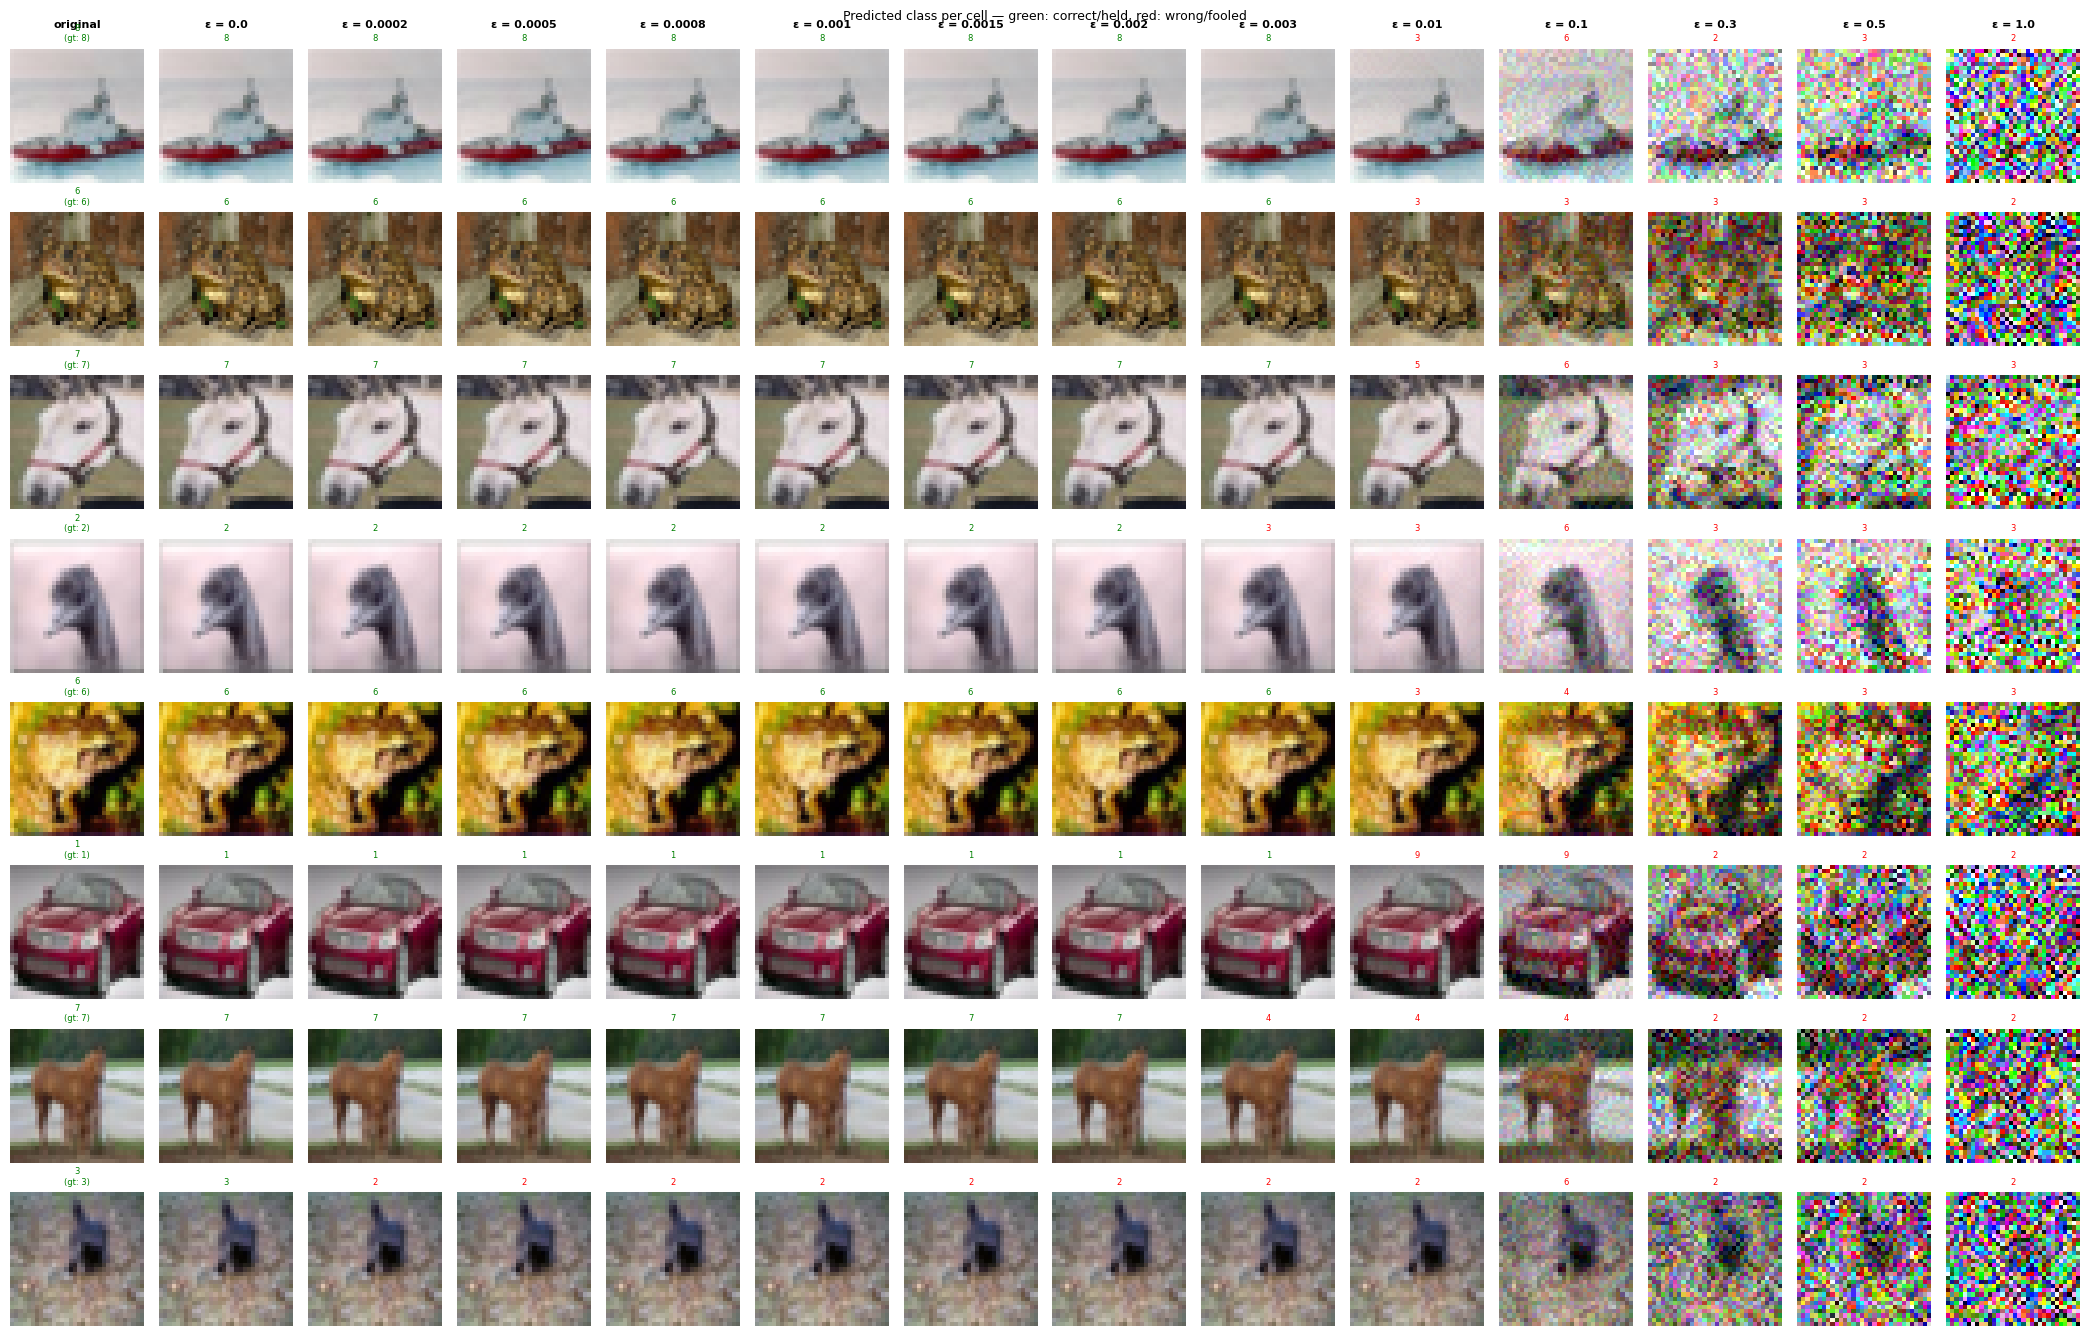

In [20]:
visualize_adversarial_examples(results, epsilons)